# Exploring how to make cyclone relative composites using TempestExtremes NodeFileFilter and NodeFileCompose

In [1]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings

#warnings.filterwarnings('ignore')
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import seaborn as sns
import xarray as xr

## custom packages:
from download_era5_composite import timestamps_from_picks, build_manifest, download, OUT_DIR

## First method (not using anymore)

In [2]:
etc_summary = pd.read_csv('etc_summary_2.csv')
nodes_with_reports = pd.read_csv('nodes_with_reports_2.csv')

In [7]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind
0,1.0,2020-01-01 00:00:00+00:00,2020-01-05 22:00:00+00:00,2020-01-05 03:00:00+00:00,956.5094,115,0,0,0,0
1,2.0,2020-01-01 11:00:00+00:00,2020-01-04 04:00:00+00:00,2020-01-01 19:00:00+00:00,986.4200,59,0,0,0,0
2,3.0,2020-01-02 13:00:00+00:00,2020-01-06 23:00:00+00:00,2020-01-03 23:00:00+00:00,975.0175,102,0,0,0,0
3,4.0,2020-01-03 11:00:00+00:00,2020-01-08 23:00:00+00:00,2020-01-08 10:00:00+00:00,990.7425,133,0,0,0,0
4,5.0,2020-01-04 00:00:00+00:00,2020-01-06 18:00:00+00:00,2020-01-06 15:00:00+00:00,951.6381,62,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...
58,69.0,2020-03-23 17:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-25 19:00:00+00:00,992.0688,197,0,0,0,0
59,70.0,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137,465,24,266,175
60,72.0,2020-03-30 00:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1000.3920,38,113,16,0,97
61,73.0,2020-03-30 11:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1006.8550,36,0,0,0,0


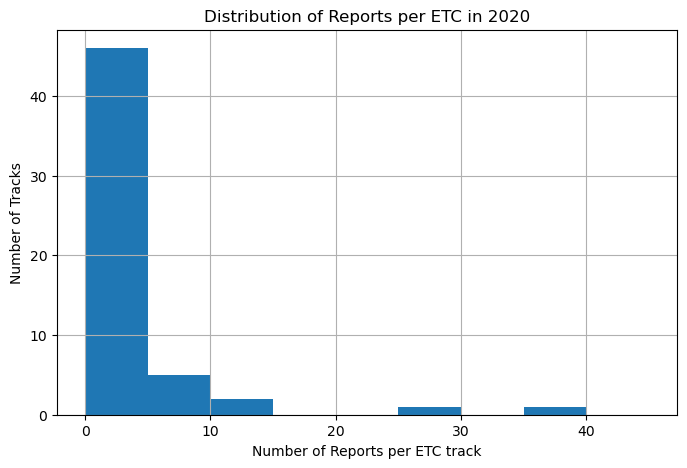

In [16]:
plt.figure(figsize=(8,5))
plt.hist(etc_summary['n_reports'], bins=np.arange(0,50,5))
plt.xlabel('Number of Reports per ETC track')
plt.ylabel('Number of Tracks')
plt.title('Distribution of Reports per ETC in 2020')
plt.grid(True);

In [13]:
print(etc_summary['n_reports'].describe())

count     65.000000
mean      37.276923
std      115.506021
min        0.000000
25%        0.000000
50%        1.000000
75%        6.000000
max      686.000000
Name: n_reports, dtype: float64


In [25]:
len(etc_summary)

65

In [ ]:
print(len(etc_summary[etc_summary['n_reports'] >=10]))
print(len(etc_summary[etc_summary['n_reports'] == 0]))

14
32


For now I'll use a threshold of 10 reports to define an "outbreak cyclone", and will just use cyclones that produce no reports as nonoutbreak cyclones

### Choosing reference time:

Later I could use KDE core onset times to use as reference times for compositing, but for now I'll just use min msl. Since several cyclones have multiple outbreak cores, it creates ambiguity in what reference time to use.

In [ ]:
tracks_oc = nodes_with_reports[nodes_with_reports['n_reports ']]

,track_id,time_hour,lat,lon,msl,n_reports,n_tornado,n_hail,n_wind
0,8245,2020-01-01 00:00:00+00:00,67.25,-27.50,972.9406,0,0,0,0
1,8245,2020-01-01 01:00:00+00:00,67.50,-26.75,972.2656,0,0,0,0
2,8245,2020-01-01 02:00:00+00:00,67.50,-26.00,971.7975,0,0,0,0
3,8245,2020-01-01 03:00:00+00:00,67.50,-26.00,971.3462,0,0,0,0
4,8245,2020-01-01 04:00:00+00:00,67.75,-25.25,971.3850,0,0,0,0
...,...,...,...,...,...,...,...,...,...
7314,8320,2020-03-31 19:00:00+00:00,44.50,-105.25,1004.1650,0,0,0,0
7315,8320,2020-03-31 20:00:00+00:00,44.50,-104.50,1003.3780,0,0,0,0
7316,8320,2020-03-31 21:00:00+00:00,44.50,-103.75,1002.9580,0,0,0,0
7317,8320,2020-03-31 22:00:00+00:00,43.75,-102.75,1003.1310,0,0,0,0


In [33]:
nodes_with_reports['n_reports'].describe()

count    7319.000000
mean        0.331056
std         2.746133
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        82.000000
Name: n_reports, dtype: float64

## Creating two TempestExtremes nodefiles, each with one node per cyclone (the node at that cyclone's time_min_msl)

In [ ]:
# RAW_NODEFILE = Path("/data1/lepique/era5_test/trajsens2.ERA5.hourly_kiefer.txt")
# ETC_SUMMARY = Path("etc_summary.csv")

# OUTBREAK_NODEFILE = Path("outbreak_cyclones_min_msl.txt")
# NONOUTBREAK_NODEFILE = Path("nonoutbreak_cyclones_min_msl.txt")

# OUTBREAK_THRESHOLD = 10

In [ ]:
# def _clean_track_id(s):
#     """Handle track_id values saved as floats or strings
#     """
#     return pd.to_numeric(s).astype("int64")

# def _parse_te_line_time(parts):
#     return pd.Timestamp(
#         year=int(parts[6]),
#         month=int(parts[7]),
#         day=int(parts[8]),
#         hour=int(parts[9]),
#         tz="UTC",
#     )

In [ ]:
# def write_min_msl_nodefile(
#         raw_nodefile,
#         selected_times,
#         outfile,
# ):
#     """
#     Write a TE nodefile with one single-note trajectory per selected track
     
#     Parameters:
#      ---------
#     raw_nodefile: path-like
#         Original TempestExtremes StitchNodes nodefile
#     selected_times: pd.Series
#         Index = integer track_id. values = UTC Timestamp of min MSL.
#     outfile: path-like
#         Output nodefile path
#     """

#     raw_nodefile = Path(raw_nodefile)
#     outfile = Path(outfile)

#     selected_times = pd.to_datetime(selected_times, utc=True)

#     found = set()
#     current_track_id = 0

#     with raw_nodefile.open("r") as fin, outfile.open("w") as fout:
#         for line in fin:
#             parts = line.split()

#             if not parts:
#                 continue

#             if parts[0] == "start":
#                 current_track_id +=1
#                 continue

#             if current_track_id not in selected_times.index:
#                 continue

#             node_time = _parse_te_line_time(parts)
#             target_time = selected_times.loc[current_track_id]

#             if node_time == target_time:
#                 ## single node trajectory, preserving the original data line exactly.
#                 fout.write("start\n")
#                 fout.write(line if line.endswith("\n") else line + "\n")
#                 found.add(current_track_id)

#     missing = sorted(set(selected_times.index) - found)
#     if missing:
#         print(
#             f"[WARNING] {len(missing)} selected tracks were not written because "
#             f"their min-MSL timestamp was not found in {raw_nodefile}."
#         )
#         print("First missing track_ids:", missing[:10])

#     print(f"Wrote {len(found):,} nodes to {outfile}")


In [ ]:
# ## Load track level summary
# etc_summary = pd.read_csv(ETC_SUMMARY)

# etc_summary["track_id"] = _clean_track_id(etc_summary["track_id"])
# etc_summary["time_min_msl"] = pd.to_datetime(etc_summary["time_min_msl"], utc=True)
# etc_summary["n_reports"] = pd.to_numeric(etc_summary["n_reports"])


In [ ]:
# ## define cyclone groups
# outbreak = etc_summary.loc[etc_summary["n_reports"] >= OUTBREAK_THRESHOLD].copy()
# nonoutbreak = etc_summary.loc[etc_summary["n_reports"] == 0].copy()
# print(f"Outbreak cyclones    : {len(outbreak):,}")
# print(f"Nonoutbreak cyclones : {len(nonoutbreak):,}")

Outbreak cyclones    : 14
Nonoutbreak cyclones : 32


In [ ]:
# ## series: index = track_id, value = min_MSL time
# outbreak_times = outbreak.set_index("track_id")["time_min_msl"]
# nonoutbreak_times = nonoutbreak.set_index("track_id")["time_min_msl"]

In [ ]:
# write_min_msl_nodefile(
#     RAW_NODEFILE,
#     outbreak_times,
#     OUTBREAK_NODEFILE,
# )
# write_min_msl_nodefile(
#     RAW_NODEFILE,
#     nonoutbreak_times,
#     NONOUTBREAK_NODEFILE,
# )

Wrote 14 nodes to outbreak_cyclones_min_msl.txt
Wrote 32 nodes to nonoutbreak_cyclones_min_msl.txt


In [ ]:
# def parse_snapshot_nodefile_times(nodefile_path):
#     """
#     Extract (track_id, datetime) from a single-snapshot nodefile
#     written by write_min_msl_nodefile.
#     Header line: 'start'
#     Node line:   grid_i grid_j lon lat [extra cols...] YYYY MM DD offset_hours
#     """
#     records = []
#     nodefile_path = Path(nodefile_path)
#     tid = 0
#     with nodefile_path.open() as f:
#         for line in f:
#             parts = line.split()
#             if not parts:
#                 continue
#             if parts[0] == "start":
#                 tid += 1
#                 continue
#             # Last 4 tokens are always YYYY MM DD offset
#             yyyy, mm, dd, off = int(parts[-4]), int(parts[-3]), int(parts[-2]), float(parts[-1])
#             lon, lat = float(parts[2]), float(parts[3])
#             dt = pd.Timestamp(year=yyyy, month=mm, day=dd, tz="UTC") \
#                + pd.Timedelta(hours=off)
#             records.append({
#                 "track_id": tid,
#                 "lon":      lon,
#                 "lat":      lat,
#                 "datetime": dt,
#                 "date_str": dt.strftime("%Y-%m-%d"),
#                 "hour_str": dt.strftime("%H:00"),
#             })
#     return pd.DataFrame(records)

# oc_nodes  = parse_snapshot_nodefile_times("outbreak_cyclones_min_msl.txt")
# noc_nodes = parse_snapshot_nodefile_times("nonoutbreak_cyclones_min_msl.txt")
# all_nodes = pd.concat([oc_nodes, noc_nodes]).drop_duplicates(subset=["datetime"])

# print(f"OC nodes  : {len(oc_nodes)}")
# print(f"NOC nodes : {len(noc_nodes)}")
# print(f"Unique timestamps (deduplicated): {len(all_nodes)}")
# print(f"\nDate range: {all_nodes['datetime'].min()} -> {all_nodes['datetime'].max()}")
# print(f"\nAll timestamps:")
# print(all_nodes[["track_id","datetime","lon","lat"]].to_string())

OC nodes  : 14
NOC nodes : 32
Unique timestamps (deduplicated): 45

Date range: 2020-01-01 00:00:00+00:00 -> 2020-03-31 23:00:00+00:00

All timestamps:
    track_id                  datetime     lon    lat
0          1 2020-01-10 23:00:00+00:00  259.50  27.25
1          2 2020-01-14 13:00:00+00:00  354.75  52.50
2          3 2020-02-03 20:00:00+00:00  253.50  39.75
3          4 2020-02-08 00:00:00+00:00  292.50  44.75
4          5 2020-02-13 11:00:00+00:00  280.75  39.50
5          6 2020-02-15 00:00:00+00:00  321.00  57.75
6          7 2020-03-07 06:00:00+00:00  326.25  61.00
7          8 2020-03-16 09:00:00+00:00  328.25  63.50
8          9 2020-03-14 03:00:00+00:00  241.50  43.75
9         10 2020-03-22 02:00:00+00:00  313.75  55.75
10        11 2020-03-26 19:00:00+00:00  289.75  61.75
11        12 2020-03-27 19:00:00+00:00  302.25  47.50
12        13 2020-03-28 22:00:00+00:00  267.00  42.00
13        14 2020-03-31 23:00:00+00:00  281.25  33.25
0          1 2020-01-03 04:00:00+00:00

## Trying a different method

In [3]:
MASTER_NODEFILE = "/data1/lepique/era5_test/track_sensitivities/tracks_hourly_2020_9.txt"     # <-- the StitchNodes nodefile used for the pilot

def diagnose(master_nodefile, etc_summary):
    print("=== etc_summary columns ===")
    print(list(etc_summary.columns))
    print("\n=== etc_summary dtypes (relevant) ===")
    print(etc_summary.dtypes)
    print("\n=== etc_summary head ===")
    print(etc_summary.head())

    print("\n=== first 6 lines of master nodefile ===")
    with open(master_nodefile) as f:
        for i, line in enumerate(f):
            print(repr(line.rstrip("\n")))
            if i >= 5:
                break

In [4]:
diagnose(MASTER_NODEFILE, etc_summary)

=== etc_summary columns ===
['track_id', 'track_start', 'track_end', 'time_min_msl', 'min_msl', 'n_steps', 'n_reports', 'n_tornado', 'n_hail', 'n_wind']

=== etc_summary dtypes (relevant) ===
track_id        float64
track_start      object
track_end        object
time_min_msl     object
min_msl         float64
n_steps           int64
n_reports         int64
n_tornado         int64
n_hail            int64
n_wind            int64
dtype: object

=== etc_summary head ===
   track_id                track_start                  track_end  \
0       1.0  2020-01-01 00:00:00+00:00  2020-01-05 22:00:00+00:00   
1       2.0  2020-01-01 11:00:00+00:00  2020-01-04 04:00:00+00:00   
2       3.0  2020-01-02 13:00:00+00:00  2020-01-06 23:00:00+00:00   
3       4.0  2020-01-03 11:00:00+00:00  2020-01-08 23:00:00+00:00   
4       5.0  2020-01-04 00:00:00+00:00  2020-01-06 18:00:00+00:00   

                time_min_msl   min_msl  n_steps  n_reports  n_tornado  n_hail  \
0  2020-01-05 03:00:00+00:00  95

In [5]:
## CONFIG
COL_TRACKID = "track_id"
COL_NREPORTS = "n_reports"
COL_TIMEMSL = "time_min_msl"

## node data columns AFTER the two grid indices:
NODE_DATA_COLS = ["lon", "lat", "msl", "phis"]

OUTBREAK_THRESHOLD = 10

## restrict to these calendar months (Jan, Feb, Mar), as in stormevents_utils
MONTHS = (1, 2, 3)

OUT_OC = "outbreak_cyclones_min_msl.txt"
OUT_NOC = "nonoutbreak_cyclones_min_msl.txt"

## ERA5 config
# ERA5 (Stage D)
ERA5_SINGLE_LEVEL_VARS = [
    "mean_sea_level_pressure",
    "total_column_water_vapour",
    "2m_temperature",
]
ERA5_PRESSURE_LEVEL_VARS = [
    "temperature", "u_component_of_wind",
    "v_component_of_wind", "specific_humidity",
]
ERA5_PRESSURE_LEVELS = ["850"]
ERA5_AREA = [65, -135, 15, -55]       # N, W, S, E
ERA5_OUT_DIR = "era5_composite_2020"


In [6]:
## Parse nodefile 
def parse_nodefile(path, data_cols):
    """
    Parse TE Stitchnodes nodefile. track_id is 1-indexed (first block = 1) to match etc_summary. 
    """

    rows = []
    with open(path) as f:
        lines = [ln.rstrip("\n") for ln in f]

    i = 0
    tid = 0
    n_data = len(data_cols)
    while i < len(lines):
        parts = lines[i].split()
        if not parts:
            i += 1
            continue
        if parts[0] == "start":
            tid +=1
            n_steps = int(parts[1])
            for k in range(1, n_steps + 1):
                np_ = lines[i+k].split()
                grid_i, grid_j = int(np_[0]), int(np_[1])
                data_vals = np_[2:2 + n_data]
                yyyy, mm, dd, off = np_[2 + n_data:2 + n_data + 4]
                row = {
                    "track_id": float(tid),
                    "grid_i": grid_i, "grid_j": grid_j,
                    "year": int(yyyy), "month": int(mm),
                    "day": int(dd), "offset": off,
                }
                for c, v in zip(data_cols, data_vals):
                    row[c] = float(v)
                rows.append(row)
            i += n_steps + 1
        else:
            i +=1
    
    df = pd.DataFrame(rows)
    df["datetime"] = df.apply(
        lambda r: pd.Timestamp(year=r["year"], month=r["month"],
                               day = r["day"], tz="UTC")
                               + pd.Timedelta(hours = float(r["offset"])),
        axis=1,
    )

    return df


In [7]:
## label OC/NOC, pikc min_MSL node
def select_minmsl_nodes(nodes_df, etc_summary):
    es = etc_summary[[COL_TRACKID, COL_NREPORTS, COL_TIMEMSL]].copy()
    es[COL_TIMEMSL] = pd.to_datetime(es[COL_TIMEMSL], utc=True)
    es["is_oc"] = es[COL_NREPORTS] >= OUTBREAK_THRESHOLD

    ## keep only cyclones whose reference time (min MSL) falls in MONTHS
    es = es[es[COL_TIMEMSL].dt.month.isin(MONTHS)]

    picks = []
    for _, r in es.iterrows():
        tid = r[COL_TRACKID]
        cand = nodes_df[nodes_df["track_id"] == tid]
        if cand.empty:
            print(f"WARNING: track {tid} not in nodefile")
            continue
        dt_diff = (cand["datetime"] - r[COL_TIMEMSL]).abs()
        node = cand.loc[dt_diff.idxmin()].copy()
        if dt_diff.min() > pd.Timedelta(hours=1):
            print(f"NOTE: track {tid} nearest node {dt_diff.min()} from min_MSL")
        node["is_oc"] = r["is_oc"]
        node["n_reports"] = r[COL_NREPORTS]
        picks.append(node)
    
    picks_df = pd.DataFrame(picks).reset_index(drop=True)
    print(f"\n  OC  (n_reports >= {OUTBREAK_THRESHOLD}): {picks_df['is_oc'].sum()}")
    print(f"  NOC (n_reports <  {OUTBREAK_THRESHOLD}): {(~picks_df['is_oc']).sum()}")

    ## warn if any node is close to the ERA5 boundary for a ~20 degree composite radius
    south_edge = ERA5_AREA[2]
    too_south = picks_df[picks_df["lat"] - 20 < south_edge]
    if len(too_south):
        print(f"\n  DOMAIN WARNING: {len(too_south)} node(s) within 20 deg of "
              f"southern boundary ({south_edge} N):")
        for _, n in too_south.iterrows():
            print(f"    track {n['track_id']:.0f}  lat={n['lat']:.2f}  "
                  f"-> radius reaches {n['lat']-20:.1f} N")
    return picks_df

In [8]:
## write single-snapshot nodefiles (what will be the input to TE)
def write_snapshot_nodefile(subset, out_path, data_cols):
    with open(out_path, "w") as f:
        for _, r in subset.iterrows():
            yyyy, mm, dd, off = int(r["year"]), int(r["month"]), int(r["day"]), r["offset"]
            data_str = "\t".join(f"{r[c]:.6f}" for c in data_cols)
            f.write("start\n")
            f.write(f"\t{int(r['grid_i'])}\t{int(r['grid_j'])}\t{data_str}"
                    f"\t{yyyy}\t{mm}\t{dd}\t{off}\n")
    print(f" wrote {len(subset)} -> {out_path}")

In [9]:
## driver 
def run_all(master_nodefile, etc_summary):
    nodes_df = parse_nodefile(master_nodefile, NODE_DATA_COLS)
    print(f"Parsed {nodes_df['track_id'].nunique()} tracks, {len(nodes_df)} nodes.")
    picks_df = select_minmsl_nodes(nodes_df, etc_summary)
    write_snapshot_nodefile(picks_df[picks_df["is_oc"]],  OUT_OC,  NODE_DATA_COLS)
    write_snapshot_nodefile(picks_df[~picks_df["is_oc"]], OUT_NOC, NODE_DATA_COLS)
    return nodes_df, picks_df

In [10]:
nodes_df, picks_df = run_all(MASTER_NODEFILE, etc_summary)

Parsed 230 tracks, 28528 nodes.

  OC  (n_reports >= 10): 14
  NOC (n_reports <  10): 49

  DOMAIN WARNING: 6 node(s) within 20 deg of southern boundary (15 N):
    track 11  lat=27.25  -> radius reaches 7.2 N
    track 19  lat=25.50  -> radius reaches 5.5 N
    track 21  lat=28.50  -> radius reaches 8.5 N
    track 26  lat=30.50  -> radius reaches 10.5 N
    track 27  lat=28.50  -> radius reaches 8.5 N
    track 72  lat=33.25  -> radius reaches 13.2 N
 wrote 14 -> outbreak_cyclones_min_msl.txt
 wrote 49 -> nonoutbreak_cyclones_min_msl.txt


## Downloading ERA5 data for NodeFileCompose

In [11]:
timestamps = timestamps_from_picks(picks_df)
date_groups = build_manifest(timestamps)

In [13]:
# preview first with dry run
download(date_groups, OUT_DIR, dry_run=True)

 [dry] era5_sfc_2020-01-01.nc hours=['19:00'] vars=['mean_sea_level_pressure', 'total_column_water_vapour', '2m_temperature']
 [dry] era5_plev_2020-01-01.nc hours=['19:00'] vars=['temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_humidity']
 [dry] era5_sfc_2020-01-03.nc hours=['23:00'] vars=['mean_sea_level_pressure', 'total_column_water_vapour', '2m_temperature']
 [dry] era5_plev_2020-01-03.nc hours=['23:00'] vars=['temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_humidity']
 [dry] era5_sfc_2020-01-05.nc hours=['03:00'] vars=['mean_sea_level_pressure', 'total_column_water_vapour', '2m_temperature']
 [dry] era5_plev_2020-01-05.nc hours=['03:00'] vars=['temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_humidity']
 [dry] era5_sfc_2020-01-06.nc hours=['15:00'] vars=['mean_sea_level_pressure', 'total_column_water_vapour', '2m_temperature']
 [dry] era5_plev_2020-01-06.nc hours=['15:00'] vars=['temperature', 'u_component_of_wind', 

In [ ]:
download(date_groups, OUT_DIR, dry_run=False)

 [skip] era5_sfc_2020-01-01.nc
 [skip] era5_plev_2020-01-01.nc
 [skip] era5_sfc_2020-01-03.nc
 [skip] era5_plev_2020-01-03.nc
 [skip] era5_sfc_2020-01-05.nc
 [skip] era5_plev_2020-01-05.nc
 [skip] era5_sfc_2020-01-06.nc
 [skip] era5_plev_2020-01-06.nc
 [skip] era5_sfc_2020-01-08.nc
 [skip] era5_plev_2020-01-08.nc
 [skip] era5_sfc_2020-01-10.nc
 [skip] era5_plev_2020-01-10.nc
 [skip] era5_sfc_2020-01-12.nc
 [skip] era5_plev_2020-01-12.nc
 [skip] era5_sfc_2020-01-13.nc
 [skip] era5_plev_2020-01-13.nc
 [skip] era5_sfc_2020-01-14.nc
 [skip] era5_plev_2020-01-14.nc
 [skip] era5_sfc_2020-01-17.nc
 [skip] era5_plev_2020-01-17.nc
 [skip] era5_sfc_2020-01-18.nc
 [skip] era5_plev_2020-01-18.nc
 [skip] era5_sfc_2020-01-19.nc
 [skip] era5_plev_2020-01-19.nc
 [skip] era5_sfc_2020-01-20.nc
 [skip] era5_plev_2020-01-20.nc
 [skip] era5_sfc_2020-01-23.nc
 [skip] era5_plev_2020-01-23.nc
 [skip] era5_sfc_2020-01-25.nc
 [skip] era5_plev_2020-01-25.nc
 [skip] era5_sfc_2020-01-27.nc
 [skip] era5_plev_2020-0

2026-06-17 16:31:29,490 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-06-17 16:31:29,491 INFO Request ID is b6a0d9f0-c7de-4e40-b06a-31b87aa49c35
2026-06-17 16:31:29,630 INFO status has been updated to accepted
2026-06-17 16:31:51,292 INFO status has been updated to running
2026-06-17 16:32:02,820 INFO status has been updated to successful


bb6e196d57673b398221ea3b8958c586.nc:   0%|          | 0.00/574k [00:00<?, ?B/s]

 -> saved era5_sfc_2020-02-03.nc
 requesting era5_plev_2020-02-03.nc ...


2026-06-17 16:32:05,083 INFO Request ID is 4209d2ac-4031-4dad-b991-58061bb8d54c
2026-06-17 16:32:05,241 INFO status has been updated to accepted
2026-06-17 16:32:19,109 INFO status has been updated to running
2026-06-17 16:32:38,381 INFO status has been updated to successful


...

 -> saved era5_plev_2020-02-24.nc
 requesting era5_sfc_2020-02-25.nc ...


2026-06-17 16:43:09,819 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-06-17 16:43:09,820 INFO Request ID is 58954d16-69a9-47c2-97ff-27577620342a
2026-06-17 16:43:10,347 INFO status has been updated to accepted
2026-06-17 16:43:34,930 INFO status has been updated to running
2026-06-17 16:43:46,472 INFO status has been updated to successful


bc34f7fd2c69235152aff1f2d2533140.nc:   0%|          | 0.00/570k [00:00<?, ?B/s]

 -> saved era5_sfc_2020-02-25.nc
 requesting era5_plev_2020-02-25.nc ...


2026-06-17 16:43:48,680 INFO Request ID is 58894de5-8abd-48fd-a132-1f0f587c1c3f
2026-06-17 16:43:48,808 INFO status has been updated to accepted
2026-06-17 16:44:03,340 INFO status has been updated to running
